# Pointwise calibration — VFC at I = 10 A across all conditions

Instead of fitting one full polar curve, we fit the cell voltage at a single current (10 A) across every operating condition. This isolates the low-current regime (kinetics + OCV + ohmic), making the parameter sensitivity clearer.

In [11]:
import sys, math, warnings, time
from pathlib import Path
from copy import deepcopy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna
from scipy.integrate import solve_ivp

optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

# Resolve project root so the project modules import cleanly
project_folder_name = "MFC2024"
project_root = next((p for p in [Path.cwd(), *Path.cwd().parents]
                     if p.name == project_folder_name), None)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# Project imports
from config.settings    import solver_variable_names, solver_flux_names
from config.initialize  import parameters, operating_inputs, init_x_for
from model.dualscale    import PEMFC
from model.kinetic_eq   import Rproton, eta_ccl, fdrop
from model.coefficients import n_cell

I_TARGET = 10.0  # A -- the single current point we calibrate against

In [12]:
# ---- Cell 2: Import experiment data ----
exp_file       = project_root / "data" / "Polar_curves.xlsx"
polardata_exp  = pd.read_excel(exp_file, sheet_name=None)  # dict: cond_key -> DataFrame
print(f"Loaded {len(polardata_exp)} conditions from {exp_file.name}")

Loaded 12 conditions from Polar_curves.xlsx


## 1. Extract VFC at I ≈ 10 A for every condition

Each sheet contains a polarization curve. We pick the row whose `I_LOAD` is closest to 10 A and convert the stack voltage `VFC` to per-cell voltage by dividing by `n_cell`.

In [13]:
# ---- Cell 3: Extract experimental VFC at I=10 A for every condition ----
vfc_10A = {}  # cond_key -> (i_actual, ucell_per_cell)
for cond_key, df in polardata_exp.items():
    i_exp = df["I_LOAD"].to_numpy(dtype=float)
    v_exp = df["VFC"].to_numpy(dtype=float) / n_cell  # stack voltage -> per-cell voltage
    idx   = int(np.argmin(np.abs(i_exp - I_TARGET)))  # nearest row to 10 A
    vfc_10A[cond_key] = (float(i_exp[idx]), float(v_exp[idx]))

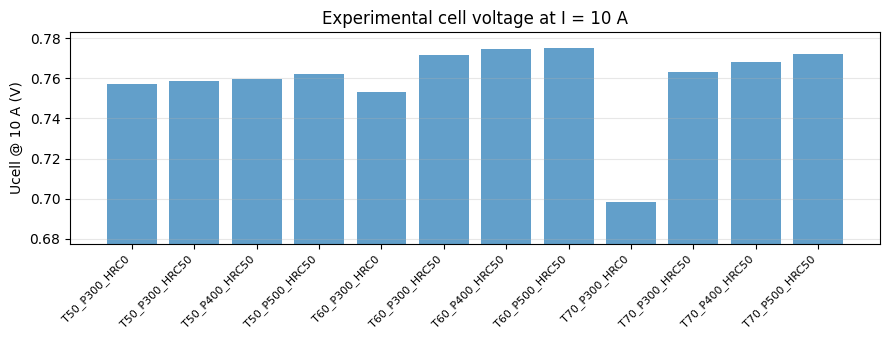

In [14]:
# ---- Cell 4: Bar chart of experimental Ucell @ 10 A ----
cond_keys = list(vfc_10A.keys())
ucell_exp_arr = np.array([vfc_10A[k][1] for k in cond_keys])  # target voltages

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(range(len(cond_keys)), ucell_exp_arr, color="tab:blue", alpha=0.7)
ax.set_xticks(range(len(cond_keys)))
ax.set_xticklabels(cond_keys, rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Ucell @ 10 A (V)")
ax.set_title("Experimental cell voltage at I = 10 A")
ax.set_ylim(ucell_exp_arr.min() * 0.97, ucell_exp_arr.max() * 1.01)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Simulation function — one point per condition

`simulate_point` parses the condition key, configures the dual-scale model, and runs one BDF integration at `I_TARGET`. It returns the simulated cell voltage (or `None` on failure).

In [15]:
# ---- Cell 5: Single-point simulator (robust to failures and NaN) ----
def simulate_point(cond_key, params_override):
    # Decode the condition key (e.g. T60_P400_HRC50 -> 60degC, 4 bar gauge + 1e5, 50% RH)
    T_des = int(cond_key.split("_")[0][1:])
    P_des = int(cond_key.split("_")[1][1:]) * 100 + 1e5
    RHC   = int(cond_key.split("_")[2][3:])

    p  = deepcopy(parameters);  p.update(params_override)  # apply trial parameters
    p["aux_system"] = False  # disable BoP -- we only calibrate stack-level params
    op = deepcopy(operating_inputs)
    op["Tfc"]       = T_des + 273.15
    op["Pa_des"]    = P_des
    op["Pc_des"]    = P_des
    op["Phi_c_des"] = RHC / 100

    i_density = I_TARGET / p["Aact"]  # convert load current to current density
    op["current_density"] = lambda t, _i=i_density: _i

    try:
        model = PEMFC(param=p, operating_inputs=op,
                      variable_names=solver_variable_names,
                      flux_names=solver_flux_names)
        x0  = init_x_for("dual-scale", op, model.parameters)
        sol = solve_ivp(model.dxdt, (0, 30), x0, method="BDF", max_step=2e-1)  # 30 s -> steady state
    except Exception:
        return None    # constructor / initializer / solver itself raised -> skip this point

    if not sol.success:
        return None    # solver flagged failure (step size collapse, divergence, etc.)

    last = {k: sol.y[idx, -1] for idx, k in enumerate(model.variable_names)}
    if not np.all(np.isfinite(list(last.values()))):
        return None    # final state contains NaN/Inf even though solver claimed success

    try:
        Rmem, _, _ = Rproton(last, model.parameters, op)
        eta_c      = eta_ccl(last, op, model.parameters)
    except Exception:
        return None    # kinetic/transport eval blew up on the (possibly extreme) final state

    Rmem_sum = float(np.sum(Rmem))
    if not (np.isfinite(Rmem_sum) and np.isfinite(eta_c)):
        return None    # NaN in Rmem or overpotential -> Ucell would be NaN

    Ucell = p["OCV"] - i_density * (Rmem_sum + p["Re"]) - eta_c  # full cell voltage balance
    if not (np.isfinite(Ucell) and 0.0 < Ucell < 1.3):
        return None    # unphysical voltage -> reject so Optuna penalises it as a fail
    return float(Ucell)

## 3. Sanity check — does the model even reach the right voltage range?

Before launching the 200-trial Optuna study, simulate every condition once with the **warm-start** (manually tuned) parameters and overlay the result on the experimental targets. If the simulation is wildly off across the board, no amount of searching will close the gap — the bounds or model structure need to be revisited first. The shared definitions (`COND_KEYS`, `U_EXP`, normalization constants, `warm_start_params`) live in this cell so the objective and the final plot can reuse them.

Simulating all conditions with warm-start parameters ...
Done in 37.8 s.   Failed/NaN: 0/12


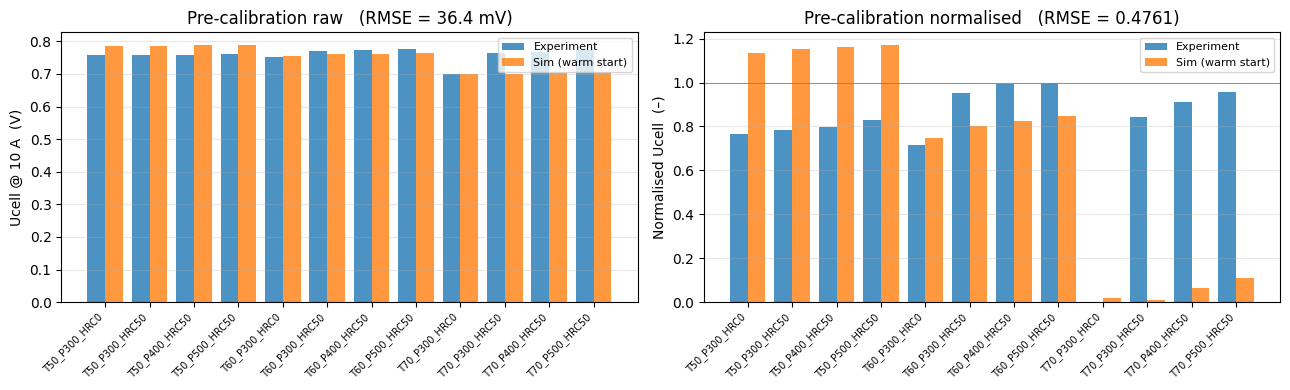


Condition             Exp (V)    Sim (V)    dV (mV)
--------------------------------------------------
T50_P300_HRC0          0.7572     0.7853       28.1
T50_P300_HRC50         0.7585     0.7868       28.3
T50_P400_HRC50         0.7595     0.7875       28.0
T50_P500_HRC50         0.7622     0.7881       25.9
T60_P300_HRC0          0.7533     0.7558        2.4
T60_P300_HRC50         0.7715     0.7599      -11.6
T60_P400_HRC50         0.7748     0.7618      -12.9
T60_P500_HRC50         0.7751     0.7636      -11.5
T70_P300_HRC0          0.6986     0.7000        1.4
T70_P300_HRC50         0.7630     0.6994      -63.6
T70_P400_HRC50         0.7682     0.7034      -64.9
T70_P500_HRC50         0.7719     0.7071      -64.7


In [16]:
# ---- Cell 6: Sanity-check simulation with the warm-start (manual) parameters ----
COND_KEYS = list(vfc_10A.keys())
U_EXP     = np.array([vfc_10A[k][1] for k in COND_KEYS])  # raw target Ucell vector (V)

# Min-max normalization constants from experiment -- applied identically to sim so the two stay comparable
U_MIN, U_MAX = float(U_EXP.min()), float(U_EXP.max())
U_SPAN       = U_MAX - U_MIN                              # voltage spread across conditions (~0.08 V)
U_EXP_NORM   = (U_EXP - U_MIN) / U_SPAN                   # exp targets mapped to [0, 1]

# Warm-start parameters carried over from manual_polar.ipynb -- reused as Optuna's first trial
warm_start_params = {
    "OCV": 0.84, "i0_c_ref": 1.1556, "kappa_c": 2.624, "tau": 1.554,
    "Re": 9.521e-06, "epsilon_mc": 0.1836, "epsilon_gdl": 0.6,
    "epsilon_c": 0.223, "epsilon_cl": 0.1588, "a_slim": 0.02,
    "b_slim": 0.25, "a_switch": 0.1, "Hcl": 1.47e-5, "Hgdl": 2.85e-4,
}

# Run the model once at every condition with warm_start_params
print("Simulating all conditions with warm-start parameters ...")
t0 = time.perf_counter()
u_sim_raw  = [simulate_point(k, warm_start_params) for k in COND_KEYS]            # list of float or None
u_sim_init = np.array([np.nan if u is None else u for u in u_sim_raw], dtype=float)  # None -> NaN
t_elapsed  = time.perf_counter() - t0
n_fail     = int(np.sum(~np.isfinite(u_sim_init)))
print(f"Done in {t_elapsed:.1f} s.   Failed/NaN: {n_fail}/{len(COND_KEYS)}")

# Pre-calibration error metrics
u_sim_init_n   = (u_sim_init - U_MIN) / U_SPAN                                   # normalised sim
rmse_init_raw  = float(np.sqrt(np.nanmean((u_sim_init   - U_EXP)      ** 2)))    # V
rmse_init_norm = float(np.sqrt(np.nanmean((u_sim_init_n - U_EXP_NORM) ** 2)))    # dimensionless

# Side-by-side bars (raw + normalised)
x = np.arange(len(COND_KEYS))
fig, (ax_r, ax_n) = plt.subplots(1, 2, figsize=(13, 4))

ax_r.bar(x - 0.2, U_EXP,      width=0.4, color="tab:blue",   alpha=0.8, label="Experiment")
ax_r.bar(x + 0.2, u_sim_init, width=0.4, color="tab:orange", alpha=0.8, label="Sim (warm start)")
ax_r.set_xticks(x); ax_r.set_xticklabels(COND_KEYS, rotation=45, ha="right", fontsize=7)
ax_r.set_ylabel("Ucell @ 10 A  (V)")
ax_r.set_title(f"Pre-calibration raw   (RMSE = {rmse_init_raw*1000:.1f} mV)")
ax_r.grid(True, axis="y", alpha=0.3); ax_r.legend(fontsize=8)

ax_n.bar(x - 0.2, U_EXP_NORM,   width=0.4, color="tab:blue",   alpha=0.8, label="Experiment")
ax_n.bar(x + 0.2, u_sim_init_n, width=0.4, color="tab:orange", alpha=0.8, label="Sim (warm start)")
ax_n.set_xticks(x); ax_n.set_xticklabels(COND_KEYS, rotation=45, ha="right", fontsize=7)
ax_n.set_ylabel("Normalised Ucell  (–)")
ax_n.set_title(f"Pre-calibration normalised   (RMSE = {rmse_init_norm:.4f})")
ax_n.axhline(0, color="grey", linewidth=0.6); ax_n.axhline(1, color="grey", linewidth=0.6)
ax_n.grid(True, axis="y", alpha=0.3); ax_n.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Per-condition delta -- a uniform offset suggests OCV/Re; condition-dependent gap suggests kinetics / mass transport
print(f"\n{'Condition':18s}  {'Exp (V)':>9s}  {'Sim (V)':>9s}  {'dV (mV)':>9s}")
print("-" * 50)
for k, ue, us in zip(COND_KEYS, U_EXP, u_sim_init):
    dv     = (us - ue) * 1000 if np.isfinite(us) else float("nan")
    us_str = f"{us:9.4f}" if np.isfinite(us) else "     fail"
    dv_str = f"{dv:9.1f}" if np.isfinite(dv) else "      nan"
    print(f"{k:18s}  {ue:9.4f}  {us_str}  {dv_str}")

## 4. Optuna objective (normalised)

Both the experimental targets and the simulated voltages are min-max normalised with the **same** constants — `U_MIN` and `U_MAX` of the experiment, set in the sanity-check cell. This maps exp to `[0, 1]` and rescales sim onto the same axis, amplifying the relative pattern across conditions so the SSE is more sensitive to the *shape* of the response, not just the absolute level.

In [17]:
# ---- Cell 7: Optuna objective using normalised SSE over all conditions @ 10 A ----
# Uses COND_KEYS, U_EXP_NORM, U_MIN, U_SPAN defined in the sanity-check cell above.
def objective(trial):
    params_trial = {
        "OCV":         trial.suggest_float("OCV",         0.80,  1.00),
        "i0_c_ref":    trial.suggest_float("i0_c_ref",    0.01,  15.0,  log=True),
        "kappa_c":     trial.suggest_float("kappa_c",     0.5,   3.0),
        # "tau":         trial.suggest_float("tau",         1.0,   4.0),
        # "Re":          trial.suggest_float("Re",          5e-7,  1e-5,  log=True),
        "epsilon_mc":  trial.suggest_float("epsilon_mc",  0.15,  0.5),
        "epsilon_gdl": trial.suggest_float("epsilon_gdl", 0.5,   0.8),
        "epsilon_c":   trial.suggest_float("epsilon_c",   0.05,  0.35),
        "epsilon_cl":  trial.suggest_float("epsilon_cl",  0.1,   0.5),
        # "a_slim":      trial.suggest_float("a_slim",      5e-3,  0.3,   log=True),
        # "b_slim":      trial.suggest_float("b_slim",      0.1,   0.9),
        # "a_switch":    trial.suggest_float("a_switch",    0.05,  0.5),
        "Hcl":         trial.suggest_float("Hcl",         1e-5,  3e-5,  log=True),
        "Hgdl":        trial.suggest_float("Hgdl",        1e-4,  4e-4,  log=True),
    }

    sse, n_fail = 0.0, 0
    for cond_key, u_target_norm in zip(COND_KEYS, U_EXP_NORM):
        u_sim = simulate_point(cond_key, params_trial)
        if u_sim is None:
            n_fail += 1
            continue
        u_sim_norm = (u_sim - U_MIN) / U_SPAN          # same transform applied to sim -> dimensionless
        sse += (u_sim_norm - u_target_norm) ** 2       # squared error in normalised units
    sse += n_fail * 1.0  # penalty per failed condition -- matches magnitude of a fully off normalised error
    return sse

## 5. Run the study

Same Optuna setup as `polar.ipynb` — TPE sampler, warm-start with `warm_start_params` (so the very first trial reproduces the bars you just plotted), configurable budget.

In [18]:
# ---- Cell 8: Run Optuna study ----
N_TRIALS = 200          # number of parameter sets to try
TIMEOUT  = 60 * 120     # 2 h wall-clock cap

study = optuna.create_study(direction="minimize",
                            sampler=optuna.samplers.TPESampler(seed=42))

study.enqueue_trial(warm_start_params)   # reuse the same manual values shown in the sanity check

study.optimize(objective, n_trials=N_TRIALS, timeout=TIMEOUT, show_progress_bar=True)

best_params = study.best_params
print(f"\nCompleted {len(study.trials)} trials.   Best SSE = {study.best_value:.6f}")
print(f"{'Parameter':15s}  {'Best fit':>12s}")
print("-" * 30)
for k, v in best_params.items():
    print(f"  {k:13s}  {v:12.4g}")

  0%|          | 0/200 [00:00<?, ?it/s]


Completed 166 trials.   Best SSE = 1.062493
Parameter            Best fit
------------------------------
  OCV                  0.8001
  i0_c_ref              14.93
  kappa_c               2.995
  epsilon_mc           0.3266
  epsilon_gdl          0.5095
  epsilon_c            0.3479
  epsilon_cl           0.1043
  Hcl               2.992e-05
  Hgdl              0.0002247


## 6. Result — measured vs. calibrated Ucell @ 10 A

Compare against the **pre-calibration RMSE** printed in section 3 to confirm the optimizer actually improved the fit.

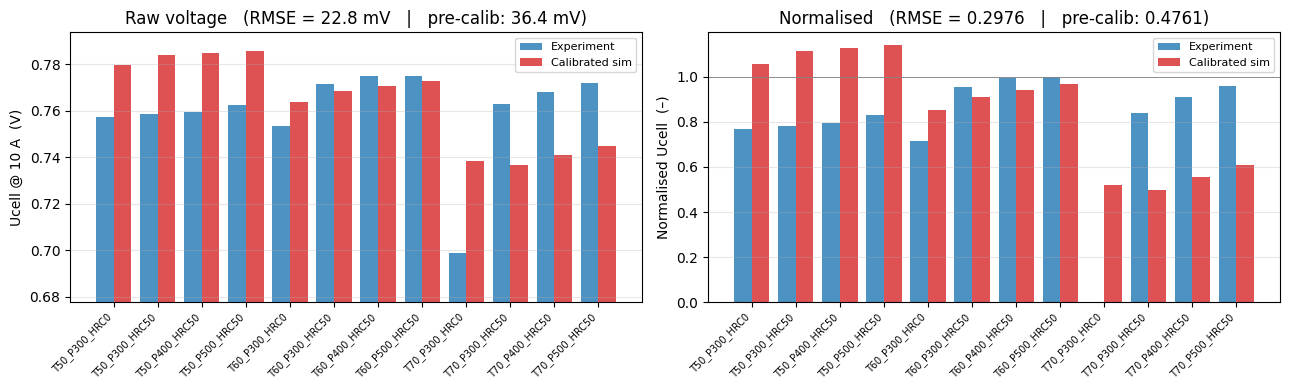


Failed/NaN conditions: 0/12

Condition             Exp (V)    Sim (V)    dV (mV)    Exp_n    Sim_n
----------------------------------------------------------------------
T50_P300_HRC0          0.7572     0.7795       22.3    0.766    1.057
T50_P300_HRC50         0.7585     0.7839       25.4    0.783    1.115
T50_P400_HRC50         0.7595     0.7849       25.4    0.796    1.128
T50_P500_HRC50         0.7622     0.7858       23.6    0.832    1.140
T60_P300_HRC0          0.7533     0.7637       10.4    0.715    0.851
T60_P300_HRC50         0.7715     0.7683       -3.2    0.953    0.911
T60_P400_HRC50         0.7748     0.7706       -4.1    0.996    0.942
T60_P500_HRC50         0.7751     0.7728       -2.3    1.000    0.970
T70_P300_HRC0          0.6986     0.7383       39.7    0.000    0.519
T70_P300_HRC50         0.7630     0.7367      -26.3    0.841    0.498
T70_P400_HRC50         0.7682     0.7410      -27.3    0.910    0.554
T70_P500_HRC50         0.7719     0.7450      -26.9    0.95

In [19]:
# ---- Cell 9: Re-simulate every condition with best_params and plot (raw + normalised) ----
u_sim_list = [simulate_point(k, best_params) for k in COND_KEYS]                 # call once per condition
u_sim_arr  = np.array([u if u is not None else np.nan for u in u_sim_list])      # None -> NaN for plotting

# Apply the SAME normalization used during optimisation
u_sim_norm = (u_sim_arr - U_MIN) / U_SPAN     # dimensionless sim values

rmse_raw  = float(np.sqrt(np.nanmean((u_sim_arr  - U_EXP)      ** 2)))           # V
rmse_norm = float(np.sqrt(np.nanmean((u_sim_norm - U_EXP_NORM) ** 2)))           # dimensionless

x = np.arange(len(COND_KEYS))
fig, (ax_raw, ax_norm) = plt.subplots(1, 2, figsize=(13, 4))

# --- Raw V bar chart ---
ax_raw.bar(x - 0.2, U_EXP,     width=0.4, color="tab:blue", alpha=0.8, label="Experiment")
ax_raw.bar(x + 0.2, u_sim_arr, width=0.4, color="tab:red",  alpha=0.8, label="Calibrated sim")
ax_raw.set_xticks(x); ax_raw.set_xticklabels(COND_KEYS, rotation=45, ha="right", fontsize=7)
ax_raw.set_ylabel("Ucell @ 10 A  (V)")
ax_raw.set_title(f"Raw voltage   (RMSE = {rmse_raw*1000:.1f} mV   |   pre-calib: {rmse_init_raw*1000:.1f} mV)")
ax_raw.set_ylim(min(U_EXP.min(), np.nanmin(u_sim_arr)) * 0.97,
                max(U_EXP.max(), np.nanmax(u_sim_arr)) * 1.01)
ax_raw.grid(True, axis="y", alpha=0.3); ax_raw.legend(fontsize=8)

# --- Normalised bar chart (what the optimizer actually saw) ---
ax_norm.bar(x - 0.2, U_EXP_NORM, width=0.4, color="tab:blue", alpha=0.8, label="Experiment")
ax_norm.bar(x + 0.2, u_sim_norm, width=0.4, color="tab:red",  alpha=0.8, label="Calibrated sim")
ax_norm.set_xticks(x); ax_norm.set_xticklabels(COND_KEYS, rotation=45, ha="right", fontsize=7)
ax_norm.set_ylabel("Normalised Ucell  (–)")
ax_norm.set_title(f"Normalised   (RMSE = {rmse_norm:.4f}   |   pre-calib: {rmse_init_norm:.4f})")
ax_norm.axhline(0, color="grey", linewidth=0.6); ax_norm.axhline(1, color="grey", linewidth=0.6)
ax_norm.grid(True, axis="y", alpha=0.3); ax_norm.legend(fontsize=8)

plt.tight_layout()
plt.show()

# Per-condition table
n_fail = sum(u is None for u in u_sim_list)
print(f"\nFailed/NaN conditions: {n_fail}/{len(COND_KEYS)}")
print(f"\n{'Condition':18s}  {'Exp (V)':>9s}  {'Sim (V)':>9s}  {'dV (mV)':>9s}  {'Exp_n':>7s}  {'Sim_n':>7s}")
print("-" * 70)
for k, ue, us, uen, usn in zip(COND_KEYS, U_EXP, u_sim_arr, U_EXP_NORM, u_sim_norm):
    dv      = (us - ue) * 1000 if np.isfinite(us) else float("nan")
    us_str  = f"{us:9.4f}" if np.isfinite(us) else "     fail"
    usn_str = f"{usn:7.3f}" if np.isfinite(usn) else "   fail"
    dv_str  = f"{dv:9.1f}" if np.isfinite(dv) else "      nan"
    print(f"{k:18s}  {ue:9.4f}  {us_str}  {dv_str}  {uen:7.3f}  {usn_str}")

## 7. Optimisation convergence

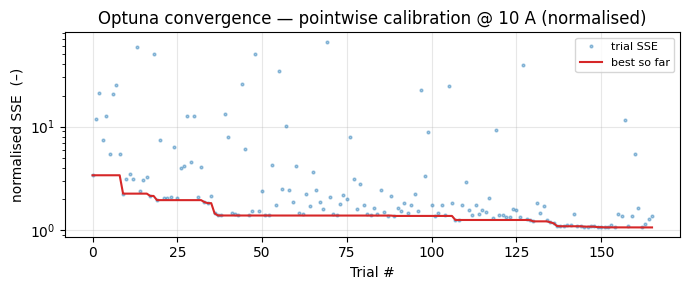

In [20]:
# ---- Cell 9: Convergence curve ----
trial_values = [t.value for t in study.trials if t.value is not None]
best_so_far  = np.minimum.accumulate(trial_values)  # running minimum -> shows progress

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(trial_values, ".", color="tab:blue", alpha=0.4, markersize=4, label="trial SSE")
ax.plot(best_so_far,  "-", color="tab:red",  linewidth=1.5,           label="best so far")
ax.set_xlabel("Trial #")
ax.set_ylabel("normalised SSE  (–)")    # objective is in normalised units now
ax.set_title("Optuna convergence — pointwise calibration @ 10 A (normalised)")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 8. Extend to 20 A and 30 A

Same pipeline, just sweep the target current. We rebuild a tiny `simulate_point_at(I)` wrapper (since the original `simulate_point` hard-codes `I_TARGET = 10 A`) and rerun the extract -> sanity-check -> Optuna -> plot loop for each current. Results land in `results_by_I` for later comparison.

In [21]:
# ---- Cell 10: Generalised single-point simulator parameterised by current ----
def simulate_point_at(cond_key, params_override, I_amp):
    T_des = int(cond_key.split("_")[0][1:])
    P_des = int(cond_key.split("_")[1][1:]) * 100 + 1e5
    RHC   = int(cond_key.split("_")[2][3:])

    p  = deepcopy(parameters);  p.update(params_override)
    p["aux_system"] = False
    op = deepcopy(operating_inputs)
    op["Tfc"]       = T_des + 273.15
    op["Pa_des"]    = P_des
    op["Pc_des"]    = P_des
    op["Phi_c_des"] = RHC / 100

    i_density = I_amp / p["Aact"]
    op["current_density"] = lambda t, _i=i_density: _i

    try:
        model = PEMFC(param=p, operating_inputs=op,
                      variable_names=solver_variable_names,
                      flux_names=solver_flux_names)
        x0  = init_x_for("dual-scale", op, model.parameters)
        sol = solve_ivp(model.dxdt, (0, 30), x0, method="BDF", max_step=2e-1)
    except Exception:
        return None
    if not sol.success:
        return None
    last = {k: sol.y[idx, -1] for idx, k in enumerate(model.variable_names)}
    if not np.all(np.isfinite(list(last.values()))):
        return None
    try:
        Rmem, _, _ = Rproton(last, model.parameters, op)
        eta_c      = eta_ccl(last, op, model.parameters)
    except Exception:
        return None
    Rmem_sum = float(np.sum(Rmem))
    if not (np.isfinite(Rmem_sum) and np.isfinite(eta_c)):
        return None
    Ucell = p["OCV"] - i_density * (Rmem_sum + p["Re"]) - eta_c
    if not (np.isfinite(Ucell) and 0.0 < Ucell < 1.3):
        return None
    return float(Ucell)

In [22]:
# ---- Cell 11: Extract experimental Ucell at 20 A and 30 A ----
def extract_vfc_at(I_amp):
    out = {}
    for cond_key, df in polardata_exp.items():
        i_exp = df["I_LOAD"].to_numpy(dtype=float)
        v_exp = df["VFC"].to_numpy(dtype=float) / n_cell
        idx   = int(np.argmin(np.abs(i_exp - I_amp)))
        out[cond_key] = (float(i_exp[idx]), float(v_exp[idx]))
    return out

I_LIST = [20.0, 30.0]
exp_by_I = {I: extract_vfc_at(I) for I in I_LIST}
for I in I_LIST:
    arr = np.array([exp_by_I[I][k][1] for k in COND_KEYS])
    print(f"I = {I:.0f} A  ->  Ucell range  {arr.min():.4f} .. {arr.max():.4f} V")

I = 20 A  ->  Ucell range  0.6456 .. 0.7197 V
I = 30 A  ->  Ucell range  0.5900 .. 0.6751 V


In [23]:
# ---- Cell 12: Optuna study per target current, warm-started from the 10 A best_params ----
def make_objective(I_amp, u_exp_norm, u_min, u_span):
    def _obj(trial):
        params_trial = {
            "OCV":         trial.suggest_float("OCV",         0.80,  1.00),
            "i0_c_ref":    trial.suggest_float("i0_c_ref",    0.01,  15.0,  log=True),
            "kappa_c":     trial.suggest_float("kappa_c",     0.5,   3.0),
            "epsilon_mc":  trial.suggest_float("epsilon_mc",  0.15,  0.5),
            "epsilon_gdl": trial.suggest_float("epsilon_gdl", 0.5,   0.8),
            "epsilon_c":   trial.suggest_float("epsilon_c",   0.05,  0.35),
            "epsilon_cl":  trial.suggest_float("epsilon_cl",  0.1,   0.5),
            "Hcl":         trial.suggest_float("Hcl",         1e-5,  3e-5,  log=True),
            "Hgdl":        trial.suggest_float("Hgdl",        1e-4,  4e-4,  log=True),
            "tau":         trial.suggest_float("tau",         1.0,   4.0),
            "Re":          trial.suggest_float("Re",          5e-7,  1e-5,  log=True),
        }
        sse, n_fail = 0.0, 0
        for cond_key, u_t_n in zip(COND_KEYS, u_exp_norm):
            u_sim = simulate_point_at(cond_key, params_trial, I_amp)
            if u_sim is None:
                n_fail += 1
                continue
            sse += ((u_sim - u_min) / u_span - u_t_n) ** 2
        sse += n_fail * 1.0
        return sse
    return _obj

N_TRIALS_EXT = 200
TIMEOUT_EXT  = 60 * 120
results_by_I = {}

for I in I_LIST:
    u_exp = np.array([exp_by_I[I][k][1] for k in COND_KEYS])
    u_min, u_max = float(u_exp.min()), float(u_exp.max())
    u_span = u_max - u_min
    u_exp_n = (u_exp - u_min) / u_span

    print(f"\n=== Optuna study @ I = {I:.0f} A ===")
    study_I = optuna.create_study(direction="minimize",
                                  sampler=optuna.samplers.TPESampler(seed=42))
    study_I.enqueue_trial(best_params)   # warm start from 10 A optimum
    study_I.optimize(make_objective(I, u_exp_n, u_min, u_span),
                     n_trials=N_TRIALS_EXT, timeout=TIMEOUT_EXT, show_progress_bar=True)

    results_by_I[I] = dict(study=study_I, best=study_I.best_params,
                            u_exp=u_exp, u_min=u_min, u_span=u_span, u_exp_n=u_exp_n)
    print(f"Best SSE @ {I:.0f} A = {study_I.best_value:.6f}")
    for k, v in study_I.best_params.items():
        print(f"  {k:13s}  {v:12.4g}")


=== Optuna study @ I = 20 A ===


  0%|          | 0/200 [00:00<?, ?it/s]

Best SSE @ 20 A = 2.101634
  OCV                  0.8003
  i0_c_ref              8.894
  kappa_c               2.998
  epsilon_mc           0.3251
  epsilon_gdl          0.5417
  epsilon_c            0.2938
  epsilon_cl           0.4844
  Hcl               2.891e-05
  Hgdl              0.0001291
  tau                   1.283
  Re                4.616e-06

=== Optuna study @ I = 30 A ===


  0%|          | 0/200 [00:00<?, ?it/s]

Best SSE @ 30 A = 1.729307
  OCV                  0.8001
  i0_c_ref              14.93
  kappa_c               2.995
  epsilon_mc           0.3266
  epsilon_gdl          0.5095
  epsilon_c            0.3479
  epsilon_cl           0.1043
  Hcl               2.992e-05
  Hgdl              0.0002247
  tau                   2.124
  Re                8.627e-06


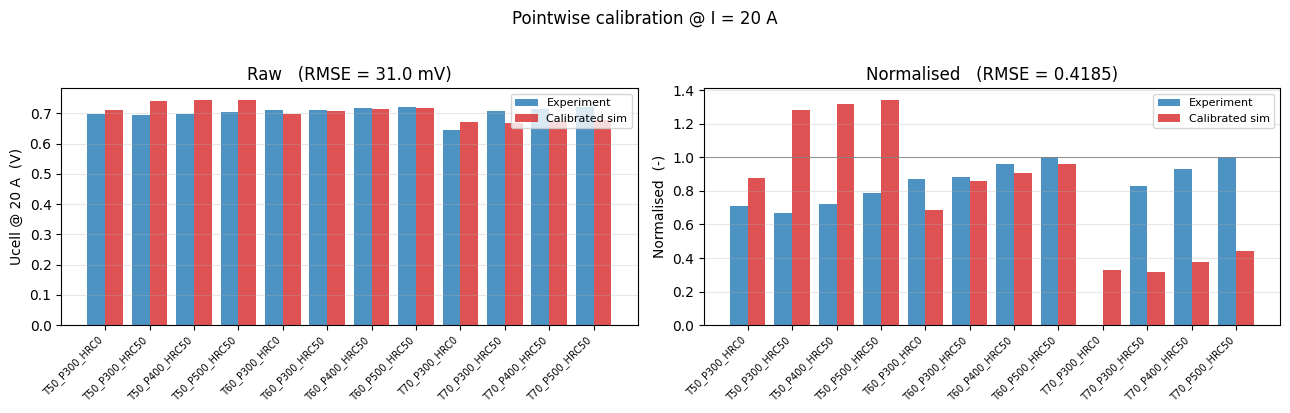

I = 20 A   failed/NaN: 0/12


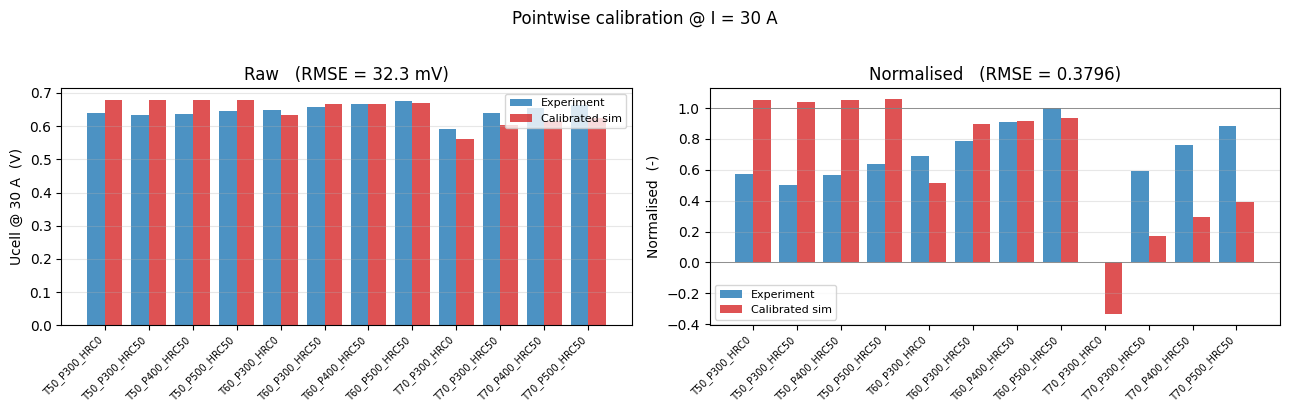

I = 30 A   failed/NaN: 0/12


In [24]:
# ---- Cell 13: Re-simulate and plot raw + normalised bars for each current ----
for I, res in results_by_I.items():
    u_sim_list = [simulate_point_at(k, res["best"], I) for k in COND_KEYS]
    u_sim_arr  = np.array([u if u is not None else np.nan for u in u_sim_list])
    u_sim_n    = (u_sim_arr - res["u_min"]) / res["u_span"]

    rmse_raw  = float(np.sqrt(np.nanmean((u_sim_arr - res["u_exp"])   ** 2)))
    rmse_norm = float(np.sqrt(np.nanmean((u_sim_n   - res["u_exp_n"]) ** 2)))
    res["u_sim"], res["rmse_raw"], res["rmse_norm"] = u_sim_arr, rmse_raw, rmse_norm

    x = np.arange(len(COND_KEYS))
    fig, (ax_r, ax_n) = plt.subplots(1, 2, figsize=(13, 4))
    ax_r.bar(x - 0.2, res["u_exp"], width=0.4, color="tab:blue", alpha=0.8, label="Experiment")
    ax_r.bar(x + 0.2, u_sim_arr,    width=0.4, color="tab:red",  alpha=0.8, label="Calibrated sim")
    ax_r.set_xticks(x); ax_r.set_xticklabels(COND_KEYS, rotation=45, ha="right", fontsize=7)
    ax_r.set_ylabel(f"Ucell @ {I:.0f} A  (V)")
    ax_r.set_title(f"Raw   (RMSE = {rmse_raw*1000:.1f} mV)")
    ax_r.grid(True, axis="y", alpha=0.3); ax_r.legend(fontsize=8)

    ax_n.bar(x - 0.2, res["u_exp_n"], width=0.4, color="tab:blue", alpha=0.8, label="Experiment")
    ax_n.bar(x + 0.2, u_sim_n,        width=0.4, color="tab:red",  alpha=0.8, label="Calibrated sim")
    ax_n.set_xticks(x); ax_n.set_xticklabels(COND_KEYS, rotation=45, ha="right", fontsize=7)
    ax_n.set_ylabel("Normalised  (-)")
    ax_n.set_title(f"Normalised   (RMSE = {rmse_norm:.4f})")
    ax_n.axhline(0, color="grey", lw=0.6); ax_n.axhline(1, color="grey", lw=0.6)
    ax_n.grid(True, axis="y", alpha=0.3); ax_n.legend(fontsize=8)
    plt.suptitle(f"Pointwise calibration @ I = {I:.0f} A", y=1.02)
    plt.tight_layout(); plt.show()

    n_fail = sum(u is None for u in u_sim_list)
    print(f"I = {I:.0f} A   failed/NaN: {n_fail}/{len(COND_KEYS)}")

In [25]:
# ---- Cell 14: Compare best parameters across the three currents ----
all_results = {10.0: {"best": best_params}}
all_results.update(results_by_I)
param_names = list(best_params.keys())

print(f"{'param':14s} " + " ".join(f"{I:>12.0f} A" for I in all_results))
print("-" * (15 + 14 * len(all_results)))
for p in param_names:
    row = " ".join(f"{all_results[I]['best'].get(p, float('nan')):12.4g}" for I in all_results)
    print(f"{p:14s} {row}")

param                    10 A           20 A           30 A
---------------------------------------------------------
OCV                  0.8001       0.8003       0.8001
i0_c_ref              14.93        8.894        14.93
kappa_c               2.995        2.998        2.995
epsilon_mc           0.3266       0.3251       0.3266
epsilon_gdl          0.5095       0.5417       0.5095
epsilon_c            0.3479       0.2938       0.3479
epsilon_cl           0.1043       0.4844       0.1043
Hcl               2.992e-05    2.891e-05    2.992e-05
Hgdl              0.0002247    0.0001291    0.0002247
